# Magnetometer Calibration Notebook

This notebook walks you through loading raw magnetometer data from the OpenLog Artemis, visualizing it, and computing hard iron calibration offsets.

**Before running:** make sure your `magcaldata.csv` file is in the `ola_data/` folder at the repo root.

## Step 1 — Load the data

In [39]:
import csv
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

path = './magcaldata.csv'

rows = []
with open(path, newline='') as f:
    reader = csv.DictReader(f)
    for row in reader:
        rows.append({k: float(v) if k not in ('Timestamp', 'Sensor') else v
                     for k, v in row.items()})

print(f'Loaded {len(rows)} samples')

mx = [r['MagX'] for r in rows]
my = [r['MagY'] for r in rows]
mz = [r['MagZ'] for r in rows]
t  = list(range(len(rows)))

Loaded 4390 samples


## Step 2 — Plot the raw magnetometer data

A well-sampled, uncalibrated magnetometer traces an **off-center ellipsoid** in 3D space. The offset from the origin is caused by hard iron distortion (permanent magnetic fields near the sensor). Your goal is to find and remove that offset so the data forms a sphere centered at the origin.

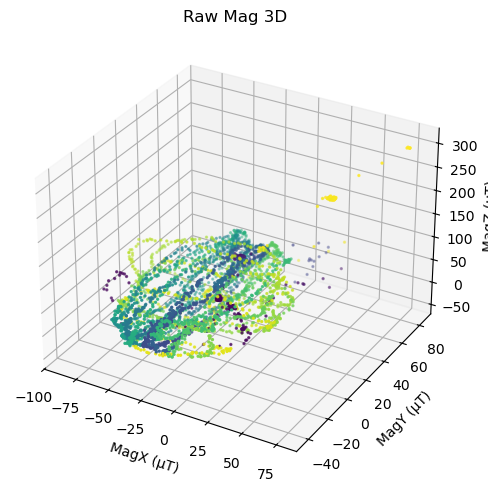

In [40]:
# 3D scatter — raw data
fig = plt.figure(figsize=(6, 5))
ax3d = fig.add_subplot(111, projection='3d')
ax3d.scatter(mx, my, mz, s=2, c=t, cmap='viridis')
ax3d.set_title('Raw Mag 3D')
ax3d.set_xlabel('MagX (µT)')
ax3d.set_ylabel('MagY (µT)')
ax3d.set_zlabel('MagZ (µT)')
plt.tight_layout()
plt.show()

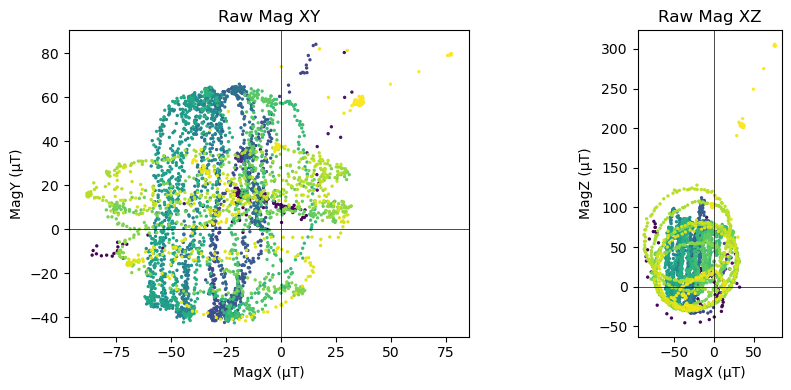

In [41]:
# XY and XZ projections — raw data
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].scatter(mx, my, s=2, c=t, cmap='viridis')
axes[0].set_aspect('equal')
axes[0].set_title('Raw Mag XY')
axes[0].set_xlabel('MagX (µT)'); axes[0].set_ylabel('MagY (µT)')
axes[0].axhline(0, color='k', lw=0.5); axes[0].axvline(0, color='k', lw=0.5)

axes[1].scatter(mx, mz, s=2, c=t, cmap='viridis')
axes[1].set_aspect('equal')
axes[1].set_title('Raw Mag XZ')
axes[1].set_xlabel('MagX (µT)'); axes[1].set_ylabel('MagZ (µT)')
axes[1].axhline(0, color='k', lw=0.5); axes[1].axvline(0, color='k', lw=0.5)

plt.tight_layout()
plt.show()

## Step 3 — Compute hard iron offsets

The hard iron offset on each axis is the midpoint between the maximum and minimum values measured:

$$\text{offset}_x = \frac{\max(X) + \min(X)}{2}$$

Repeat for Y and Z. Fill in the cells below.

In [42]:
# TODO: compute the min and max for each axis
mx_min = min(mx)
mx_max = max(mx)
my_min = min(my)
my_max = max(my)
mz_min = min(mz)
mz_max = max(mz)

print(f'MagX range: {mx_min:.2f} to {mx_max:.2f} µT')
print(f'MagY range: {my_min:.2f} to {my_max:.2f} µT')
print(f'MagZ range: {mz_min:.2f} to {mz_max:.2f} µT')

MagX range: -88.20 to 77.40 µT
MagY range: -42.60 to 84.00 µT
MagZ range: -45.60 to 305.85 µT


In [43]:
# TODO: compute the hard iron offsets (midpoint of each axis range)
offset_x = (mx_min+mx_max)/2
offset_y = (my_min+my_max)/2
offset_z = (mz_min+mz_max)/2

print(f'Hard iron offsets: X={offset_x:.3f}, Y={offset_y:.3f}, Z={offset_z:.3f} µT')

Hard iron offsets: X=-5.400, Y=20.700, Z=130.125 µT


## Step 4 — Apply the calibration

Subtract the offsets from the raw measurements to center the data at the origin.

In [44]:
# TODO: apply the offsets to produce calibrated mag vectors
mx_cal = np.array(mx) + offset_x
my_cal = np.array(my) + offset_y
mz_cal = np.array(mz) + offset_z

## Step 5 — Plot the calibrated data

After calibration the 3D scatter should look like a sphere centered near the origin. If it still looks like an ellipsoid (stretched in one direction), you may need soft iron correction too.

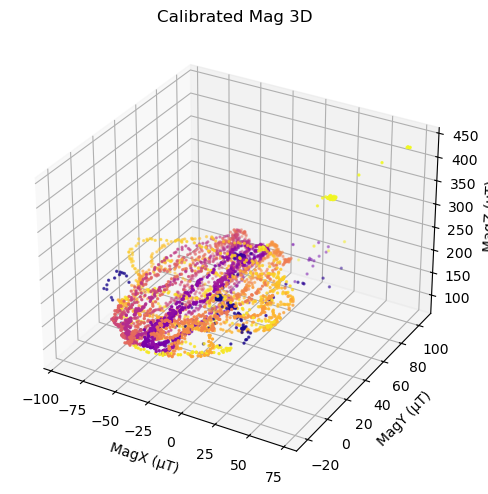

In [45]:
# 3D scatter — calibrated
fig = plt.figure(figsize=(6, 5))
ax3d = fig.add_subplot(111, projection='3d')
ax3d.scatter(mx_cal, my_cal, mz_cal, s=2, c=t, cmap='plasma')
ax3d.set_title('Calibrated Mag 3D')
ax3d.set_xlabel('MagX (µT)')
ax3d.set_ylabel('MagY (µT)')
ax3d.set_zlabel('MagZ (µT)')
plt.tight_layout()
plt.show()

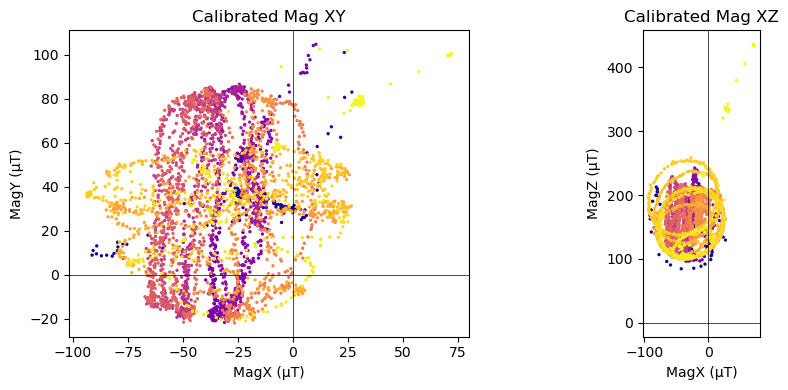

In [46]:
# XY and XZ projections — calibrated
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].scatter(mx_cal, my_cal, s=2, c=t, cmap='plasma')
axes[0].set_aspect('equal')
axes[0].set_title('Calibrated Mag XY')
axes[0].set_xlabel('MagX (µT)'); axes[0].set_ylabel('MagY (µT)')
axes[0].axhline(0, color='k', lw=0.5); axes[0].axvline(0, color='k', lw=0.5)

axes[1].scatter(mx_cal, mz_cal, s=2, c=t, cmap='plasma')
axes[1].set_aspect('equal')
axes[1].set_title('Calibrated Mag XZ')
axes[1].set_xlabel('MagX (µT)'); axes[1].set_ylabel('MagZ (µT)')
axes[1].axhline(0, color='k', lw=0.5); axes[1].axvline(0, color='k', lw=0.5)

plt.tight_layout()
plt.show()

## Step 6 — Record your calibration values

Write down your hard iron offsets — you will need them in the firmware and the sensor fusion notebook.

| Axis | Offset (µT) |
|------|-------------|
| X    |  -5.400     |
| Y    |  20.700     |
| Z    |  130.125    |

**Discussion questions:**
1. Does your 3D scatter after calibration look like a sphere? If not, what shape is it and what might cause that?
Even after calibration, my 3d scatter is still slightly elliptical, particularly on the XZ axis. This is likely due to the large battery on the side of the magnetometer. I will attempt soft iron calibration later in this notebook.
This may be less of an issue in the ocean. I was likely holding the magnetometer too close to the table, so the interactions with the table were influencing it. There won't be any metal in the ocean.

2. How complete is your coverage of orientations? Are there gaps in the scatter plot?
My coverage is reasonably thorough, but there are a few small gaps at 45 degree angles to the cardinal axes. I tried to be quite thorough and rotate the magnetometer slowly. One fun idea to get a better map is to figure out a way to stream the accelerometer data to a notebook that plots the angles in real-time, so I can see exactly what I missed.

3. What happens to your heading estimate if you skip calibration?
Without calibration, the heading estimate be will significantly off due to the constant errors in the magnetic field.